# Antecedentes

## Imports

In [73]:
import numpy as np
import pandas as pd
import sklearn
from sklearn.model_selection import KFold, StratifiedShuffleSplit
from sklearn.svm import SVR
# from sklearn.svm import NuSVR
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
# from sklearn.feature_selection import (SelectFromModel, SelectKBest,
#                                        VarianceThreshold)
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel, VarianceThreshold

## Globales

In [74]:
# 1 semilla para cosas random
RANDOM_STATE = 5712492

# 2 Minima varianza a conservar en las features
MIN_VARIANCE = 0

# 3 Separación
N_BINS= 5 #3 ##discretizer
N_SPLITS= 5 ##splitter
TEST_SIZE= 3/10 ##splitter
MAX_FEATURES = 12 #35

# 4 Algoritmo de escalamiento

# Otros que se pueden utilizar:StandardScaler(), MinMaxScaler() o Normalizer()
SCALER = StandardScaler()

# 5 Primer selector/transformador de features
feat_selector_model = XGBRegressor(
    # subsample= .8, #0.87,
    # reg_lambda= .2, #0.55,
    # reg_alpha= 0.1,
    # n_estimators= 1000, #400, #275,
    # min_child_weight= 9, #6,
    # max_depth= 8,
    # learning_rate= 0.2, #0.05,
    # colsample_bytree= 0.8
    )

FEAT_SELECTOR1 = SelectFromModel(feat_selector_model, max_features= MAX_FEATURES)

# 6 Segundo selector/transformador de features
n_pca = 6 #11
FEAT_SELECTOR2 = PCA(n_components=n_pca, random_state=RANDOM_STATE)

# 7 Algoritmo de regresión
REGRESSOR = SVR(
    #C=4, #5
    #epsilon = 0.09, #0.05
    )

# 8 Validación cruzada
METRICS = ["r2", "neg_mean_squared_error"]
CV_SPLITTER = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)



## Datos


In [75]:
# descargamos data
! gdown --id 1-kXD7CQ6pCBaBk_OkmXyvGyQrL8T69mS #Descriptores pBACE1
! gdown --id 1j75nnoi1a3PF94X2Srq8q9ftMkghZh6j #Base de datos pBACE1

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1-kXD7CQ6pCBaBk_OkmXyvGyQrL8T69mS
To: /content/Descriptores_pBACE1.xlsx
100% 7.84M/7.84M [00:00<00:00, 147MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1j75nnoi1a3PF94X2Srq8q9ftMkghZh6j
To: /content/New_pBACE1.xlsx
100% 30.1k/30.1k [00:00<00:00, 47.7MB/s]


In [76]:
#Guardamos la data como una nueva variable
data = pd.read_excel("Descriptores_pBACE1.xlsx")
df_y = pd.read_excel("New_pBACE1.xlsx") #Esta es opcional opción 1

df_y = df_y["Activity"] #Esta es opcional opción 2

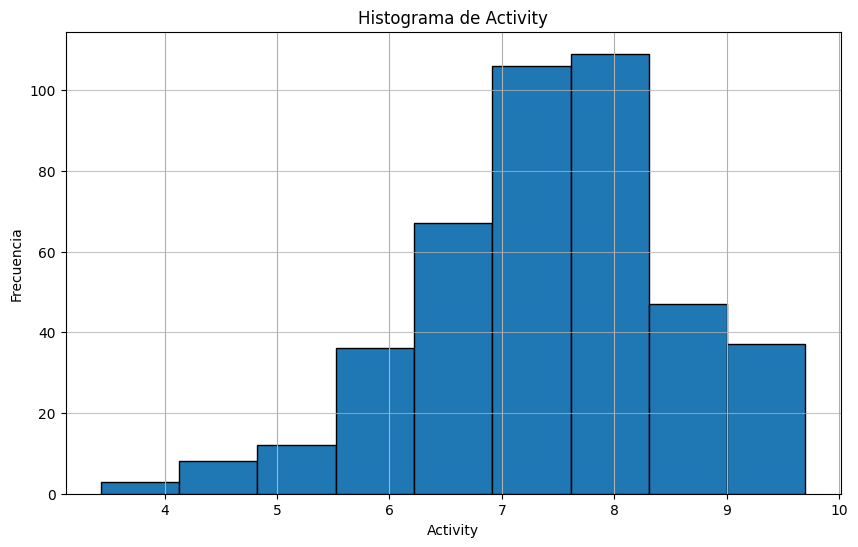

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df_y.hist(bins=9, edgecolor='black')
plt.title('Histograma de Activity')
plt.xlabel('Activity')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [78]:
# Importamos datos
#_____________________________________________
df_x = data.copy()
# df_x = df_x.drop('Activity', axis=1) # Este renglón puede ser útil #Opción 2
df_x = df_x.select_dtypes("number")  # quitar non_numeric
#_____________________________________________
df_data = df_x.assign(Activity=df_y)
df_data.shape

(425, 1424)

## Load data

In [79]:
# Cargamos data
df_x = df_x.select_dtypes("number")  # quitar non_numeric
# Agregamos columna de actividad biológica
df_data = df_x.assign(Activity=df_y)
df_data

,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,VE1_A,VE2_A,...,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2,Activity
0,0,3,30.954724,2.459862,4.802029,30.954724,1.289780,4.100933,4.027694,0.167821,...,72.212095,335.109233,8.173396,1318,34,122,141,7.277778,5.361111,5.080922
1,0,3,44.492401,2.477375,4.853464,44.492401,1.271211,4.478259,4.417682,0.126219,...,85.301487,503.107040,8.826439,4150,54,182,212,11.583333,7.666667,6.124939
2,0,3,42.420417,2.476601,4.848739,42.420417,1.285467,4.420853,4.302563,0.130381,...,84.482102,479.118274,8.711241,3541,47,170,197,9.861111,7.305556,5.161151
3,0,3,34.403575,2.464293,4.817824,34.403575,1.274206,4.211517,4.168902,0.154404,...,75.747486,379.135448,7.898655,1898,39,136,157,8.638889,6.111111,6.167491
4,0,3,35.904428,2.464362,4.818190,35.904428,1.282301,4.244751,4.180433,0.149301,...,76.855693,393.151098,7.708845,2144,40,140,161,8.888889,6.361111,5.723538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420,0,2,38.996005,2.540322,5.080645,38.996005,1.218625,4.392012,4.276888,0.133653,...,68.713627,450.142737,9.002855,3061,60,174,209,13.826389,6.770833,8.301030
421,0,2,38.996005,2.540322,5.080645,38.996005,1.218625,4.392012,4.276888,0.133653,...,68.713627,454.162803,8.410422,3061,60,174,209,13.826389,6.770833,7.481486
422,0,2,40.649283,2.540330,5.080660,40.649283,1.195567,4.449282,4.284853,0.126025,...,70.933594,490.143960,9.076740,3717,62,184,219,14.937500,7.104167,7.853872
423,0,2,40.649283,2.540330,5.080660,40.649283,1.195567,4.449282,4.284853,0.126025,...,70.933594,510.089337,10.001752,3717,62,184,219,14.937500,7.104167,7.795880


In [80]:
# dividimos train test con stratified
discretizer = sklearn.preprocessing.KBinsDiscretizer(n_bins=N_BINS, encode="ordinal", strategy="uniform")
splitter = StratifiedShuffleSplit(n_splits=N_SPLITS, test_size=TEST_SIZE, random_state=RANDOM_STATE)
# Reshape y_discrete to be a 2D array (n_samples, 1)
y_discrete = discretizer.fit_transform(df_y.values.reshape(-1, 1))
split, split_test = next(splitter.split(df_x.values, y_discrete))
fractions = ["train" if i in split else "test" for i in range(df_data.shape[0])]
df_data = df_data.assign(fraction=fractions)
df_data

,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,VE1_A,VE2_A,...,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2,Activity,fraction
0,0,3,30.954724,2.459862,4.802029,30.954724,1.289780,4.100933,4.027694,0.167821,...,335.109233,8.173396,1318,34,122,141,7.277778,5.361111,5.080922,train
1,0,3,44.492401,2.477375,4.853464,44.492401,1.271211,4.478259,4.417682,0.126219,...,503.107040,8.826439,4150,54,182,212,11.583333,7.666667,6.124939,test
2,0,3,42.420417,2.476601,4.848739,42.420417,1.285467,4.420853,4.302563,0.130381,...,479.118274,8.711241,3541,47,170,197,9.861111,7.305556,5.161151,test
3,0,3,34.403575,2.464293,4.817824,34.403575,1.274206,4.211517,4.168902,0.154404,...,379.135448,7.898655,1898,39,136,157,8.638889,6.111111,6.167491,train
4,0,3,35.904428,2.464362,4.818190,35.904428,1.282301,4.244751,4.180433,0.149301,...,393.151098,7.708845,2144,40,140,161,8.888889,6.361111,5.723538,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420,0,2,38.996005,2.540322,5.080645,38.996005,1.218625,4.392012,4.276888,0.133653,...,450.142737,9.002855,3061,60,174,209,13.826389,6.770833,8.301030,test
421,0,2,38.996005,2.540322,5.080645,38.996005,1.218625,4.392012,4.276888,0.133653,...,454.162803,8.410422,3061,60,174,209,13.826389,6.770833,7.481486,train
422,0,2,40.649283,2.540330,5.080660,40.649283,1.195567,4.449282,4.284853,0.126025,...,490.143960,9.076740,3717,62,184,219,14.937500,7.104167,7.853872,test
423,0,2,40.649283,2.540330,5.080660,40.649283,1.195567,4.449282,4.284853,0.126025,...,510.089337,10.001752,3717,62,184,219,14.937500,7.104167,7.795880,test


In [81]:
# sacamos los vectores (x, y) de interés
x_train = df_x[df_data["fraction"] == "train"].values
y_train = df_y[df_data["fraction"] == "train"].values
x_test = df_x[df_data["fraction"] == "test"].values
y_test = df_y[df_data["fraction"] == "test"].values
y_train = np.reshape(y_train, -1)
y_test = np.reshape(y_test, -1)

x_train = x_train.astype(float)
y_train = y_train.astype(float)
x_test = x_test.astype(float)
y_test = y_test.astype(float)

# x_train





# Train & Evaluate

In [82]:
# creamos pipeline: el modelo final final
steps = [
    ("var0", VarianceThreshold(MIN_VARIANCE)),
    ("scaling", SCALER),
    ("feat_selector1", FEAT_SELECTOR1),
    ("feat_selector2", FEAT_SELECTOR2),
    ("regressor", REGRESSOR)
]
pipeline = Pipeline(steps, verbose=True)
pipeline = pipeline.fit(x_train, y_train)
pipeline.set_params(verbose=False)
pipeline

[Pipeline] .............. (step 1 of 5) Processing var0, total=   0.0s
[Pipeline] ........... (step 2 of 5) Processing scaling, total=   0.0s
[Pipeline] .... (step 3 of 5) Processing feat_selector1, total=  26.6s
[Pipeline] .... (step 4 of 5) Processing feat_selector2, total=   0.0s
[Pipeline] ......... (step 5 of 5) Processing regressor, total=   0.0s


Pipeline(steps=[('var0', VarianceThreshold(threshold=0)),
                ('scaling', StandardScaler()),
                ('feat_selector1',
                 SelectFromModel(estimator=XGBRegressor(base_score=None,
                                                        booster=None,
                                                        callbacks=None,
                                                        colsample_bylevel=None,
                                                        colsample_bynode=None,
                                                        colsample_bytree=None,
                                                        device=None,
                                                        early_stopping_rounds=None,
                                                        enable_categorical=True,
                                                        eval_metric=None,
                                                        feature_types=Non...
                                                        learning_rate=None,
                                                        max_bin=None,
                                                        max_cat_threshold=None,
                                                        max_cat_to_onehot=None,
                                                        max_delta_step=None,
                                                        max_depth=None,
                                                        max_leaves=None,
                                                        min_child_weight=None,
                                                        missing=nan,
                                                        monotone_constraints=None,
                                                        multi_strategy=None,
                                                        n_estimators=1000,
                                                        n_jobs=None,
                                                        num_parallel_tree=None, ...),
                                 max_features=12)),
                ('feat_selector2', PCA(n_components=6, random_state=5712492)),
                ('regressor', SVR())])

In [83]:
# analizamos paso a paso las transformaciones
z = x_train
for (i, step) in enumerate(pipeline[:-1]):
    print(f"Step {pipeline.steps[i][0]} ({i}): {step.__class__.__name__}")
    print(f"  Input: {z.shape}. Output: {step.transform(z).shape}")
    z = step.transform(z)

Step var0 (0): VarianceThreshold
  Input: (297, 1423). Output: (297, 1237)
Step scaling (1): StandardScaler
  Input: (297, 1237). Output: (297, 1237)
Step feat_selector1 (2): SelectFromModel
  Input: (297, 1237). Output: (297, 12)
Step feat_selector2 (3): PCA
  Input: (297, 12). Output: (297, 6)


# resultados


In [84]:
# validar accuracy
metric = "r2"
# cv = sklearn.model_selection.LeaveOneOut()
cv = sklearn.model_selection.KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
cv_scores = sklearn.model_selection.cross_val_score(pipeline, x_train, y_train, cv=cv, verbose=2, scoring=metric)
scorer = sklearn.metrics.get_scorer(metric)
pd.DataFrame([{"train": scorer(pipeline, x_train, y_train),
               "cv": np.mean(cv_scores),
               "test": scorer(pipeline, x_test, y_test),
               "metric": metric}])

[CV] END .................................................... total time=  23.2s
[CV] END .................................................... total time=  19.7s
[CV] END .................................................... total time=  22.7s
[CV] END .................................................... total time=  22.5s
[CV] END .................................................... total time=  20.6s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  1.8min finished


,train,cv,test,metric
0,0.697325,0.511663,0.634268,r2
